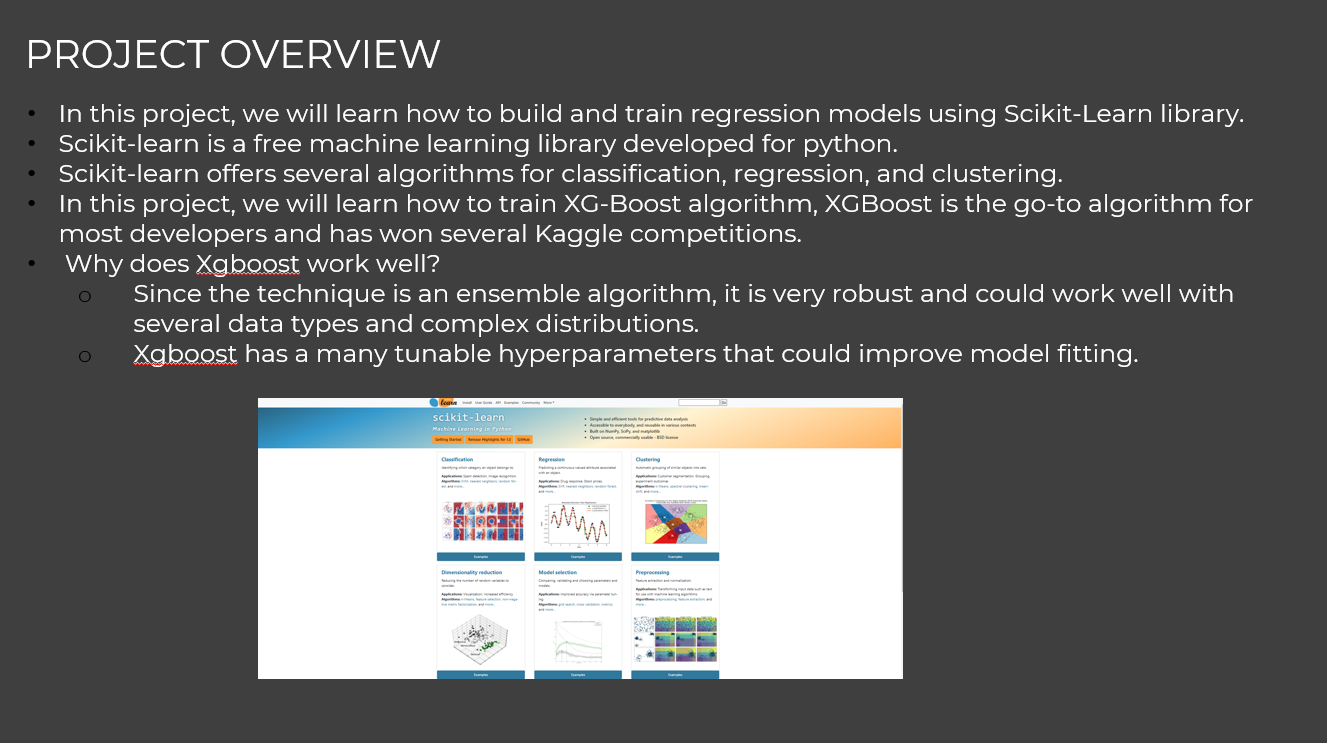

# FINAL CAPSTONE PROJECT

- In this hands-on project, we will train an XG-Boost regression model to predict university admission.
- Tasks:
    - 1. Load "university_admission.csv" data and Split it into training and testing
    - 2. Train a regression model  
    - 3. Assess trained model performance
    - 4. Plot trained model predictions vs. ground truth output
    - 5. What is R2?

In [1]:
# Run this cell once, then restart the kernel before running the next cell.
%pip install --upgrade "xgboost>=2.1.4"
import sklearn
import xgboost
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Personal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
scikit-learn: 1.5.2
xgboost: 3.4.1


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Personal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


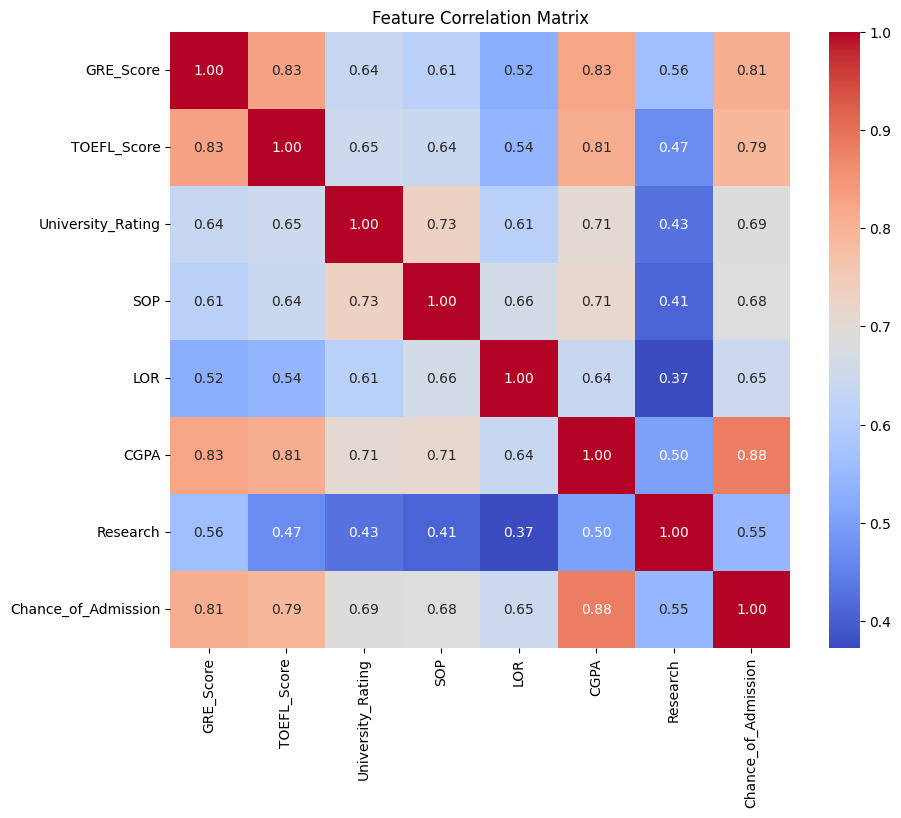

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'colsample_bytree': np.float64(0.7511572371061874), 'gamma': np.float64(0.00018205657658407274), 'learning_rate': np.float64(0.17160445029754812), 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 445, 'reg_alpha': np.float64(0.00024586032763280086), 'reg_lambda': np.float64(2.3359635026261603), 'subsample': np.float64(0.8320457481218804)}
R² Score: 0.9105
Mean Squared Error: 0.0016
Root Mean Squared Error: 0.0406
Mean Absolute Error: 0.0214
Training R² Score: 0.9930
Testing R² Score: 0.9105
R² Score Gap: 0.0825


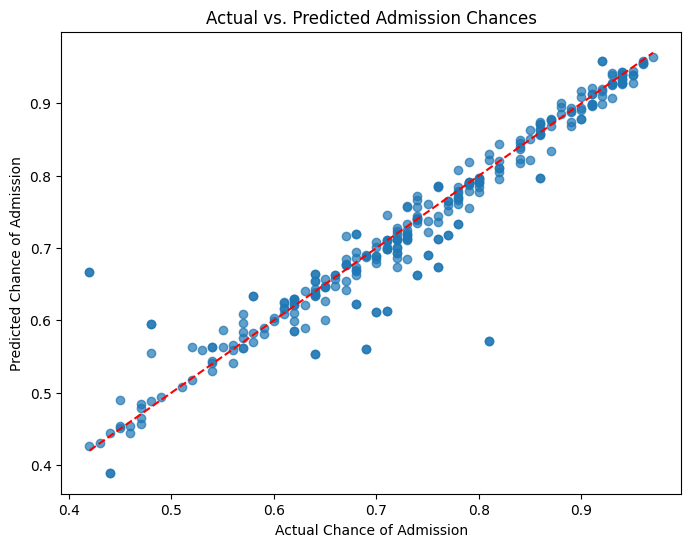

,Feature,Importance
5,CGPA,0.330338
0,GRE_Score,0.321873
6,Research,0.081263
2,University_Rating,0.070914
1,TOEFL_Score,0.069472
4,LOR,0.067821
3,SOP,0.058320


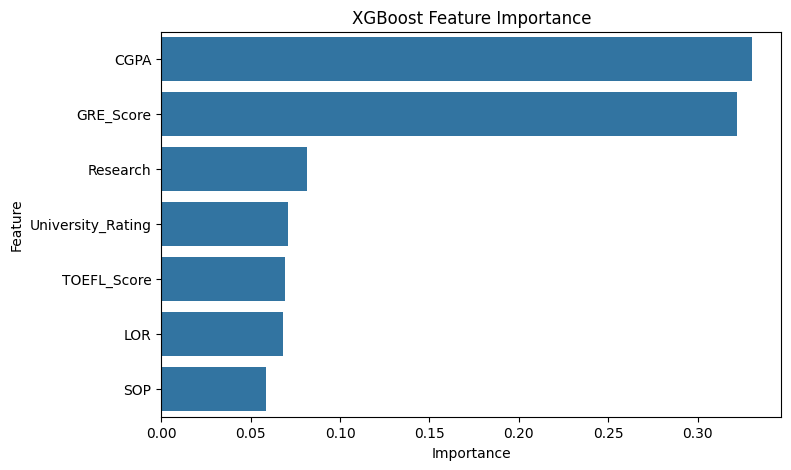

,Feature Count,CV RMSE,CV RMSE Std
0,1,0.069923,0.004351
1,2,0.066389,0.005844
2,3,0.059715,0.004460
3,4,0.056912,0.007070
4,5,0.056318,0.008923
5,6,0.053960,0.008447
6,7,0.051513,0.006922


Selected features: ['CGPA', 'GRE_Score', 'Research', 'University_Rating', 'TOEFL_Score', 'LOR', 'SOP']
Best cross-validated RMSE: 0.0515
Test R²: 0.9266
Test RMSE: 0.0367
Test MAE: 0.0203


In [2]:
# ============================================================================
# Imports and configuration
# ============================================================================
%pip install --upgrade "xgboost>=2.1.4"

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import loguniform, randint, uniform

%matplotlib inline

# ============================================================================
# Load and inspect the admission dataset
# ============================================================================
df = pd.read_csv("university_admission.csv")

display(df.head(), df.describe())
df.info()

# ============================================================================
# Explore relationships between numerical variables
# ============================================================================
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# ============================================================================
# Define features, target, and train/test split
# ============================================================================
target_column = "Chance_of_Admission"
X = df.drop(columns=target_column)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================================================================
# Tune XGBoost hyperparameters with randomized search
# ============================================================================
parameter_distributions = {
    "n_estimators": randint(100, 700),
    "max_depth": randint(1, 6),
    "learning_rate": loguniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 11),
    "gamma": loguniform(1e-4, 1.0),
    "reg_alpha": loguniform(1e-4, 1.0),
    "reg_lambda": loguniform(0.1, 10.0),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=1,
    ),
    param_distributions=parameter_distributions,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

random_search.fit(X_train, y_train)
model = random_search.best_estimator_
y_predict = model.predict(X_test)

print("Best parameters:", random_search.best_params_)

# ============================================================================
# Evaluate the tuned model on the test set
# ============================================================================
mse = mean_squared_error(y_test, y_predict)

metrics = {
    "R² Score": r2_score(y_test, y_predict),
    "Mean Squared Error": mse,
    "Root Mean Squared Error": np.sqrt(mse),
    "Mean Absolute Error": mean_absolute_error(y_test, y_predict),
    "Training R² Score": model.score(X_train, y_train),
    "Testing R² Score": model.score(X_test, y_test),
}

metrics["R² Score Gap"] = (
    metrics["Training R² Score"] - metrics["Testing R² Score"]
)

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

# ============================================================================
# Plot actual versus predicted admission chances
# ============================================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Chance of Admission")
plt.ylabel("Predicted Chance of Admission")
plt.title("Actual vs. Predicted Admission Chances")
plt.show()

# ============================================================================
# Calculate and visualize feature importance
# ============================================================================
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("XGBoost Feature Importance")
plt.show()

# ============================================================================
# Identify the best subset of features using cross-validation
# ============================================================================
ranked_features = feature_importance["Feature"].tolist()
cv_results = []

for feature_count in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:feature_count]

    candidate_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=1,
        **random_search.best_params_,
    )

    scores = cross_val_score(
        candidate_model,
        X_train[selected_features],
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )

    cv_results.append({
        "Feature Count": feature_count,
        "Features": selected_features,
        "CV RMSE": -scores.mean(),
        "CV RMSE Std": scores.std(),
    })

cv_results = pd.DataFrame(cv_results)
display(cv_results[["Feature Count", "CV RMSE", "CV RMSE Std"]])

best_row = cv_results.loc[cv_results["CV RMSE"].idxmin()]
selected_features = best_row["Features"]

print("Selected features:", selected_features)
print(f"Best cross-validated RMSE: {best_row['CV RMSE']:.4f}")

# ============================================================================
# Train and evaluate the final model with selected features
# ============================================================================
final_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_jobs=1,
    **random_search.best_params_,
)

final_model.fit(X_train[selected_features], y_train)
final_predictions = final_model.predict(X_test[selected_features])

final_mse = mean_squared_error(y_test, final_predictions)

print(f"Test R²: {r2_score(y_test, final_predictions):.4f}")
print(f"Test RMSE: {np.sqrt(final_mse):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, final_predictions):.4f}")


After building the model and training it on a wide set of hyperparameters, the performance was evaluated using the R2 score, mean squared error (MSE), mean absolute error (MAE) and root mean squared error (RMSE). Based on the train-test gap, there is slight overfitting on the training data, but the model still performs well on the test set. 

Cross validation was then used to determine the top features that contribute to the model's performance. The top features were identified as GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, and Research. Interestingly, all features were found to be important, however, the GRE Score and CGPA were found to be the most significant predictors of university admission.

The final Test R2 score was 0.9266, which is a slight, but tangible increase over the previous model's R2 score of 0.9105. This indicates that the model is able to explain approximately 92.66% of the variance in the university admission predictions, which is a strong performance for a regression model. At this stage, for the purposes of this project, we can conclude that the model is performing well and can be used to predict university admission with a high degree of accuracy.